# Sign Language Detection — Part 2: Training & Inference

**Sections:**
1. Imports & dependencies
2. Configuration
3. Load & validate dataset
4. Proper 3-way train / validation / test split
5. LSTM model with Dropout + BatchNorm regularization
6. Training with EarlyStopping + ReduceLROnPlateau
7. Learning curves
8. Evaluation: accuracy, classification report, confusion matrix
9. Per-class confidence distribution
10. Save model
11. Real-time inference

> **Prerequisite:** Run `01_data_collection.ipynb` to populate `MP_Data/`.

## 1. Imports & Dependencies

In [1]:
import cv2
import numpy as np
import os
import time
import mediapipe as mp
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam


## 2. Configuration

In [2]:
DATA_PATH            = 'MP_Data'
SEQUENCE_LENGTH      = 40
INPUT_SIZE           = 258      # Pose(132) + LH(63) + RH(63)
RANDOM_SEED          = 42

# Split ratios (test 15%, val 15%, train 70%)
VAL_SIZE             = 0.15
TEST_SIZE            = 0.15

# Training
EPOCHS               = 300
BATCH_SIZE           = 32
LEARNING_RATE        = 1e-3
DROPOUT_RATE         = 0.4
L2_LAMBDA            = 1e-4

# Inference
CONFIDENCE_THRESHOLD = 0.75

np.random.seed(RANDOM_SEED)
print('Config loaded.')


Config loaded.


## 3. Load & Validate Dataset

Sequences with wrong frame count or keypoint shape are skipped with a warning.

In [3]:
actions   = np.array(sorted(os.listdir(DATA_PATH)))
label_map = {label: i for i, label in enumerate(actions)}
sequences, labels = [], []

for action in actions:
    action_path = os.path.join(DATA_PATH, action)
    valid = skipped = 0

    for seq in os.listdir(action_path):
        seq_path    = os.path.join(action_path, seq)
        frame_files = sorted(os.listdir(seq_path), key=lambda x: int(x.split('.')[0]))

        if len(frame_files) != SEQUENCE_LENGTH:
            skipped += 1
            continue

        window = [np.load(os.path.join(seq_path, f)) for f in frame_files]
        if np.array(window).shape != (SEQUENCE_LENGTH, INPUT_SIZE):
            print(f'  [SKIP] {action}/{seq}: shape {np.array(window).shape}')
            skipped += 1
            continue

        sequences.append(window)
        labels.append(label_map[action])
        valid += 1

    print(f'  {action}: {valid} valid  |  {skipped} skipped')

X = np.array(sequences)
y = to_categorical(labels)
print(f'\nGestures  : {actions}')
print(f'Dataset   : {X.shape}')
print(f'Labels    : {y.shape}')


  Hello: 60 valid  |  0 skipped
  I: 60 valid  |  0 skipped
  ILoveYou: 60 valid  |  0 skipped
  Ok: 60 valid  |  0 skipped
  Peace: 60 valid  |  0 skipped
  Sorry: 60 valid  |  0 skipped
  ThankYou: 60 valid  |  0 skipped

Gestures  : ['Hello' 'I' 'ILoveYou' 'Ok' 'Peace' 'Sorry' 'ThankYou']
Dataset   : (420, 40, 258)
Labels    : (420, 7)


## 4. Train / Validation / Test Split

Proper 3-way split. The test set is **never seen** during training or hyperparameter tuning. Stratification preserves class balance across all subsets.

In [4]:
# Step 1 - hold out test set
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_SEED,
    stratify=np.argmax(y, axis=1)
)

# Step 2 - split remaining into train / val
val_fraction = VAL_SIZE / (1 - TEST_SIZE)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=val_fraction,
    random_state=RANDOM_SEED,
    stratify=np.argmax(y_temp, axis=1)
)

print(f'Train : {X_train.shape}')
print(f'Val   : {X_val.shape}')
print(f'Test  : {X_test.shape}')


Train : (293, 40, 258)
Val   : (64, 40, 258)
Test  : (63, 40, 258)


## 5. Build Model

3-layer LSTM with Dropout, L2 regularization, and BatchNormalization to prevent overfitting on small datasets.

In [5]:
def build_model(sequence_length, input_size, n_classes,
                dropout=DROPOUT_RATE, l2_lam=L2_LAMBDA):
    m = Sequential([
        LSTM(64, return_sequences=True,
             input_shape=(sequence_length, input_size),
             kernel_regularizer=l2(l2_lam)),
        BatchNormalization(),
        Dropout(dropout),

        LSTM(128, return_sequences=True, kernel_regularizer=l2(l2_lam)),
        BatchNormalization(),
        Dropout(dropout),

        LSTM(64, return_sequences=False, kernel_regularizer=l2(l2_lam)),
        BatchNormalization(),
        Dropout(dropout),

        Dense(64, activation='relu', kernel_regularizer=l2(l2_lam)),
        Dropout(dropout / 2),
        Dense(32, activation='relu'),
        Dense(n_classes, activation='softmax')
    ])
    m.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return m


model = build_model(SEQUENCE_LENGTH, INPUT_SIZE, len(actions))
model.summary()



Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 40, 64)            82688     
                                                                 
 batch_normalization (Batch  (None, 40, 64)            256       
 Normalization)                                                  
                                                                 
 dropout (Dropout)           (None, 40, 64)            0         
                                                                 
 lstm_1 (LSTM)               (None, 40, 128)           98816     
                                                                 
 batch_normalization_1 (Bat  (None, 40, 128)           512       
 chNormalization)                                                
                                                                 
 dropout_1 (Dropout)         (None, 40, 128)           

## 6. Train

- **EarlyStopping** (patience=40) monitors `val_loss`, restores best weights automatically.
- **ReduceLROnPlateau** halves the LR when `val_loss` stalls for 15 epochs.

In [6]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=40, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=15, min_lr=1e-6, verbose=1)
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

print(f'\nBest val accuracy : {max(history.history["val_accuracy"]):.4f}')
print(f'Stopped at epoch  : {len(history.history["loss"])}')


Epoch 1/300


10/10 [==============================] - 13s 255ms/step - loss: 2.1049 - accuracy: 0.2287 - val_loss: 2.0077 - val_accuracy: 0.0938 - lr: 0.0010
Epoch 2/300
10/10 [==============================] - 1s 56ms/step - loss: 1.7880 - accuracy: 0.3515 - val_loss: 1.9892 - val_accuracy: 0.2812 - lr: 0.0010
Epoch 3/300
10/10 [==============================] - 1s 54ms/step - loss: 1.6160 - accuracy: 0.4164 - val_loss: 1.9560 - val_accuracy: 0.2656 - lr: 0.0010
Epoch 4/300
10/10 [==============================] - 0s 50ms/step - loss: 1.3856 - accuracy: 0.5358 - val_loss: 1.9290 - val_accuracy: 0.4375 - lr: 0.0010
Epoch 5/300
10/10 [==============================] - 1s 53ms/step - loss: 1.2111 - accuracy: 0.5666 - val_loss: 1.8738 - val_accuracy: 0.4375 - lr: 0.0010
Epoch 6/300
10/10 [==============================] - 1s 52ms/step - loss: 1.0100 - accuracy: 0.6997 - val_loss: 1.8154 - val_accuracy: 0.2969 - lr: 0.0010
Epoch 7/300
10/10 [==============================] - 1s 51ms/step 

## 7. Learning Curves

Large gap between train and val = overfitting.  
Both flat and low = underfitting.

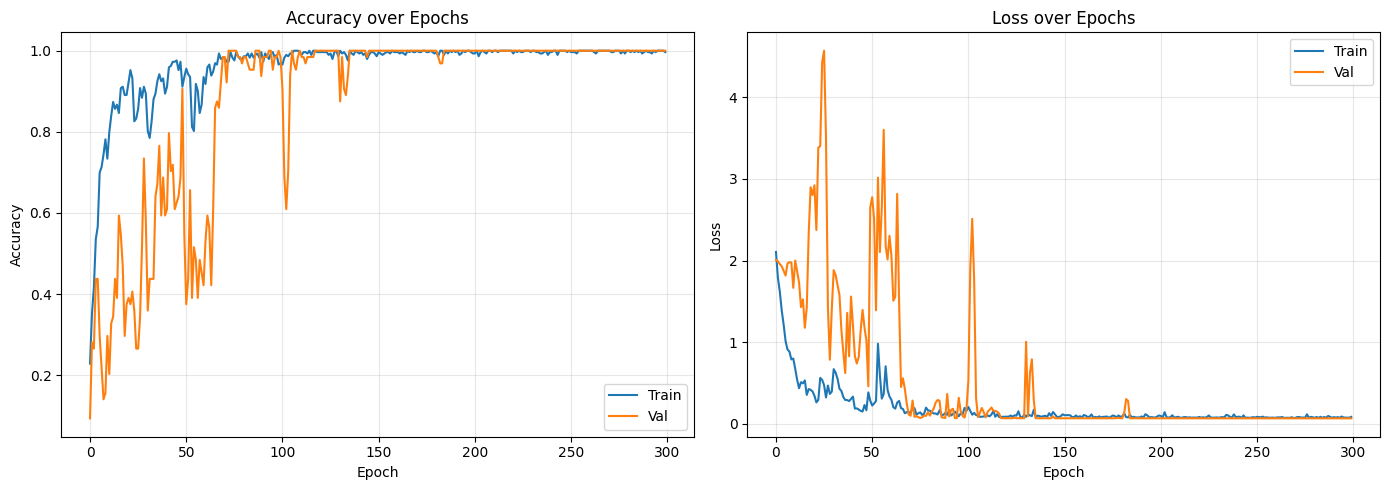

Saved: learning_curves.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'],     label='Train')
axes[0].plot(history.history['val_accuracy'], label='Val')
axes[0].set_title('Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history.history['loss'],     label='Train')
axes[1].plot(history.history['val_loss'], label='Val')
axes[1].set_title('Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: learning_curves.png')


## 8. Evaluate on Held-Out Test Set

This is the **only** time the test set is touched.

In [8]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f'Test Loss     : {test_loss:.4f}')
print(f'Test Accuracy : {test_acc:.4f}\n')

y_pred         = model.predict(X_test, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test,  axis=1)

print('Classification Report:')
print(classification_report(y_true_classes, y_pred_classes, target_names=actions))


Test Loss     : 0.0650
Test Accuracy : 1.0000

Classification Report:
              precision    recall  f1-score   support

       Hello       1.00      1.00      1.00         9
           I       1.00      1.00      1.00         9
    ILoveYou       1.00      1.00      1.00         9
          Ok       1.00      1.00      1.00         9
       Peace       1.00      1.00      1.00         9
       Sorry       1.00      1.00      1.00         9
    ThankYou       1.00      1.00      1.00         9

    accuracy                           1.00        63
   macro avg       1.00      1.00      1.00        63
weighted avg       1.00      1.00      1.00        63



## 9. Confusion Matrix

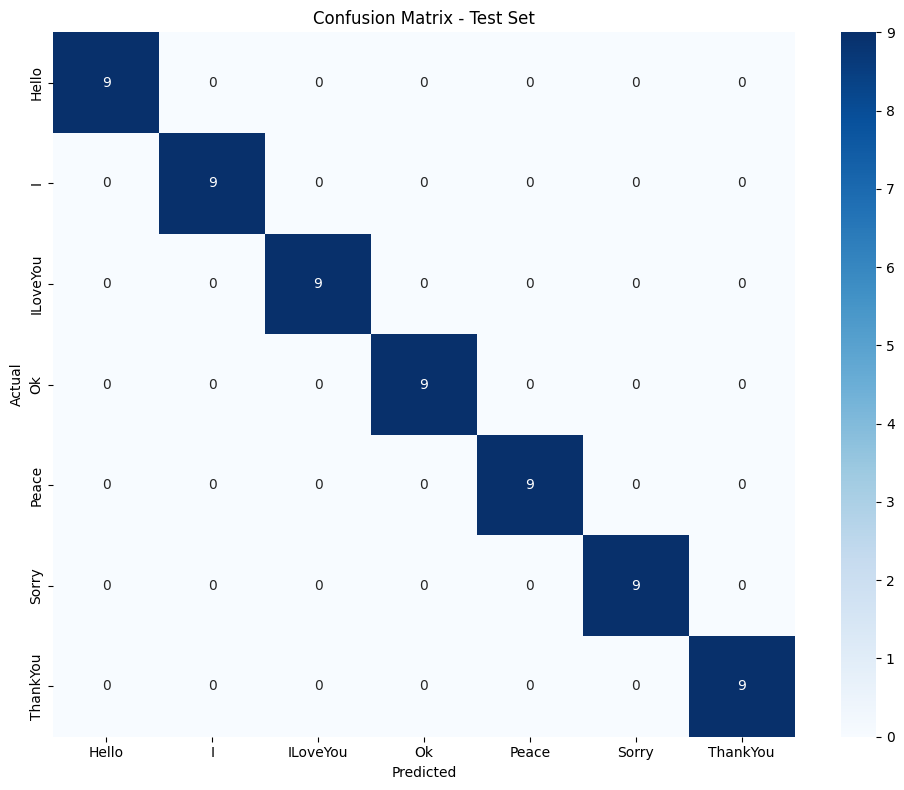

Saved: confusion_matrix.png


In [9]:
cm = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=actions, yticklabels=actions,
            cmap='Blues')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix - Test Set')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: confusion_matrix.png')


## 10. Per-Class Confidence Distribution

Low median or wide spread = a class needs more data or is ambiguous with another gesture.

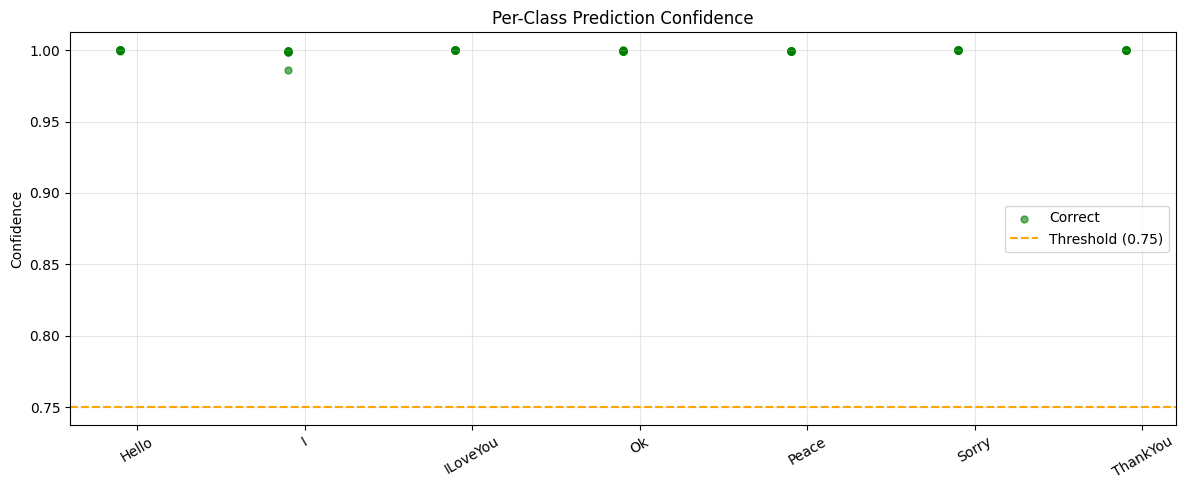

Saved: confidence_distribution.png


In [10]:
correct_conf   = {a: [] for a in actions}
incorrect_conf = {a: [] for a in actions}

for i, (t, p) in enumerate(zip(y_true_classes, y_pred_classes)):
    conf = y_pred[i, p]
    (correct_conf if t == p else incorrect_conf)[actions[t]].append(conf)

fig, ax = plt.subplots(figsize=(12, 5))
for i, action in enumerate(actions):
    c = correct_conf[action]
    e = incorrect_conf[action]
    if c: ax.scatter([i - 0.1] * len(c), c, color='green', alpha=0.6, s=25,
                     label='Correct'   if i == 0 else '')
    if e: ax.scatter([i + 0.1] * len(e), e, color='red',   alpha=0.6, s=25,
                     label='Incorrect' if i == 0 else '')

ax.axhline(CONFIDENCE_THRESHOLD, color='orange', linestyle='--',
           label=f'Threshold ({CONFIDENCE_THRESHOLD})')
ax.set_xticks(range(len(actions)))
ax.set_xticklabels(actions, rotation=30)
ax.set_ylabel('Confidence')
ax.set_title('Per-Class Prediction Confidence')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('confidence_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: confidence_distribution.png')


## 11. Save Model

In [11]:
model.save('sign_model.keras')
np.save('actions.npy', actions)
print('Saved : sign_model.keras')
print('Saved : actions.npy')
print('Actions:', actions)


Saved : sign_model.keras
Saved : actions.npy
Actions: ['Hello' 'I' 'ILoveYou' 'Ok' 'Peace' 'Sorry' 'ThankYou']


## 12. Real-Time Inference

### Controls
| Key | Action |
|-----|--------|
| `q` | Quit |
| `c` | Clear sentence |

In [12]:
mp_holistic = mp.solutions.holistic
mp_drawing  = mp.solutions.drawing_utils

model   = load_model('sign_model.keras')
actions = np.load('actions.npy')
print('Loaded actions:', actions)


def _detect(image, mp_model):
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    res   = mp_model.process(image)
    image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
    return image, res


def _draw(image, results):
    mp_drawing.draw_landmarks(image, results.left_hand_landmarks,  mp_holistic.HAND_CONNECTIONS)
    mp_drawing.draw_landmarks(image, results.right_hand_landmarks, mp_holistic.HAND_CONNECTIONS)


def _keypoints(results):
    pose = (np.array([[r.x, r.y, r.z, r.visibility] for r in results.pose_landmarks.landmark]).flatten()
            if results.pose_landmarks else np.zeros(33 * 4))
    lh   = (np.array([[r.x, r.y, r.z] for r in results.left_hand_landmarks.landmark]).flatten()
            if results.left_hand_landmarks else np.zeros(21 * 3))
    rh   = (np.array([[r.x, r.y, r.z] for r in results.right_hand_landmarks.landmark]).flatten()
            if results.right_hand_landmarks else np.zeros(21 * 3))
    return np.concatenate([pose, lh, rh])


Loaded actions: ['Hello' 'I' 'ILoveYou' 'Ok' 'Peace' 'Sorry' 'ThankYou']


In [16]:
# Inference state
sequence    = []
sentence    = []
predictions = []

cap = cv2.VideoCapture(0)
cap.set(3, 1280)
cap.set(4, 720)

with mp_holistic.Holistic(model_complexity=0,
                          min_detection_confidence=0.5,
                          min_tracking_confidence=0.5) as holistic:
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            continue
        frame = cv2.flip(frame, 1)

        image, results = _detect(frame, holistic)
        _draw(image, results)

        sequence.append(_keypoints(results))
        sequence = sequence[-SEQUENCE_LENGTH:]

        hands = results.left_hand_landmarks or results.right_hand_landmarks

        if len(sequence) == SEQUENCE_LENGTH and hands:
            res   = model.predict(np.expand_dims(sequence, axis=0), verbose=0)[0]
            idx   = np.argmax(res)
            label = actions[idx]
            conf  = res[idx]

            predictions.append(idx)
            predictions = predictions[-10:]

            # Commit when majority of last 10 frames agree at high confidence
            if len(predictions) == 10:
                most_common_idx, count = Counter(predictions).most_common(1)[0]
                if count >= 7 and conf > CONFIDENCE_THRESHOLD:
                    label = actions[most_common_idx]
                    if not sentence or label != sentence[-1]:
                        sentence.append(label)
                        sentence = sentence[-5:]

            # Confidence bar
            cv2.rectangle(image, (10, 100), (10 + int(conf * 300), 115), (0, 255, 255), -1)
            cv2.rectangle(image, (10, 100), (310, 115), (180, 180, 180), 1)
            cv2.putText(image, f'{label}: {conf:.2f}', (10, 95),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 255), 2)

        if not hands:
            predictions = []
            cv2.putText(image, 'No hands detected', (10, 120),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)

        # Sentence bar at top
        cv2.rectangle(image, (0, 0), (1280, 50), (45, 45, 45), -1)
        cv2.putText(image, ' '.join(sentence), (10, 38),
                    cv2.FONT_HERSHEY_SIMPLEX, 1.1, (255, 255, 255), 2)

        # Key hints at bottom
        cv2.putText(image, 'Q=Quit  C=Clear', (10, 710),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.55, (180, 180, 180), 1)

        cv2.imshow('Sign Language Detection', image)

        key = cv2.waitKey(1) & 0xFF
        if key == ord('q'):
            break
        elif key == ord('c'):
            sentence = []

cap.release()
cv2.destroyAllWindows()
